## Extraccion de indicadores de Honduras
Despues de limpiar y procesar el datasets de irradiacion e indicadores de riesgo
Vamos a combinarlos para crear un Score que permita selccionar el mejor candidato a nivel municpial.



## Nota sobre codigos departamenales 
En honduras los departamentos lelvan codigo de dos digitos HN00
Mienstras que los muncios usan uno de 4 digitos HN0000 entonces los primeros dos digitos mas a la izquierda son el codigo departamental.


In [302]:
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt

file_risk_indicators_1="../data/index/processed/indicadores_riesgo_1.csv"
file_risk_indicators_2="../data/index/processed/indicadores_riesgo_2.csv"
file_irradiation_yearly_monthly_totals="../data/GIS_Data_SolarPower/processed/yearly_monthly_totals.csv"
file_icae_dataset="../data/ICAEH/processed/ICAEH_2022.csv"




In [303]:

risk_indicators_1=pd.read_csv(file_risk_indicators_1)
risk_indicators_2=pd.read_csv(file_risk_indicators_2)


In [304]:


def correlation_matrix(df, metodo='pearson', mostrar_numeros=False):
    """
    Genera un correlograma (mapa de calor de correlación) optimizado para datasets
    con un gran número de columnas (32+).
    
    Parámetros:
    -----------
    df : pandas.DataFrame
        El DataFrame que contiene los datos.
    metodo : str, opcional (default='pearson')
        Método de correlación: 'pearson', 'spearman' o 'kendall'.
    mostrar_numeros : bool, opcional (default=False)
        Si es True, muestra los valores numéricos dentro de cada celda.
    """
    # 1. Seleccionar solo columnas numéricas
    df_numerico = df.select_dtypes(include=[np.number])
    
    num_cols = df_numerico.shape[1]
    if num_cols < 2:
        print("El DataFrame no contiene suficientes columnas numéricas para correlacionar.")
        return

    print(f"Generando correlograma para {num_cols} columnas numéricas...")

    # 2. Calcular la matriz de correlación
    matriz_corr = df_numerico.corr(method=metodo)

    # 3. Crear una máscara para ocultar la diagonal y la mitad superior (triángulo superior)
    mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

    # 4. Configurar el tamaño de la figura en función del número de columnas
    ancho_alto = max(12, int(num_cols * 0.5))
    plt.figure(figsize=(ancho_alto, ancho_alto * 0.8))

    # 5. Dibujar el heatmap usando Seaborn
    sns.heatmap(
        matriz_corr,
        mask=mask,
        cmap='coolwarm',       # Paleta divergente: azul (negativo) a rojo (positivo)
        vmax=1.0,
        vmin=-1.0,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.75, "label": f"Coeficiente de Correlación ({metodo.capitalize()})"},
        annot=mostrar_numeros,
        fmt=".2f",
        annot_kws={"size": max(6, 12 - int(num_cols * 0.15))} # Escala el texto si se activa
    )

    # 6. Estética y legibilidad
    plt.title(f"Correlograma de Variables ({num_cols} columnas)", fontsize=16, pad=20, weight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()


# ==========================================
# Ejemplo de uso:
# ==========================================
# df = pd.read_csv("tu_archivo.csv")
# graficar_correlograma(df)
# Si deseas ver los valores exactos en las celdas:
# graficar_correlograma(df, mostrar_numeros=True)

def remove_accent(texto):
    texto_normalizado = unicodedata.normalize('NFD', texto)
    return "".join([c for c in texto_normalizado if unicodedata.category(c) != 'Mn'])



### Indicadores de riesgo 1

In [305]:
# Aplicar la normalización a todas las columnas del DataFrame
risk_indicators_1.columns = [
    remove_accent(col).strip().lower().replace(" ", "_") 
    for col in risk_indicators_1.columns
]
risk_indicators_1.head(15)


,municipio,poblacion_expuesta_a_terremotos,poblacion_expuesta_a_inundaciones,poblacion_expuesta_a_ciclones_y_marejadas,poblacion_expuesta_a_deslizamientos,poblacion_afectada_por_sequia,poblacion_expuesta_a_incendios_forestales,poblacion_expuesta_a_plagas_forestales,inform_peligro_natural,violencia,...,capacidad_de_respuesta,gobernanza,institutional,comunicacion,infraestructura_fisica,acceso_a_educacion,capacidad_hospitalaria_covid,infraestructura,falta_de_capacidad_de_respuesta,inform_risk
0,La Ceiba,0.0,9.6,0.0,4.9,0.0,9.1,1.9,5.2,10.0,...,5.0,0.3,3.0,2.2,7.0,3.6,4.0,4.2,3.6,6.0
1,El Porvenir,0.0,9.0,0.0,0.0,0.0,7.7,0.9,3.8,9.2,...,2.7,3.0,2.9,3.9,6.7,3.2,10.0,6.0,4.6,5.7
2,Esparta,6.8,9.3,0.0,2.6,0.0,7.0,0.8,4.9,8.0,...,3.3,4.1,3.7,5.9,7.1,5.1,10.0,7.0,5.6,6.1
3,Jutiapa,0.0,9.3,0.0,4.5,0.0,7.3,1.0,4.4,8.9,...,3.3,4.2,3.8,7.3,6.5,5.4,10.0,7.3,5.8,6.7
4,La Masica,0.0,9.3,0.0,5.3,0.0,7.1,1.0,4.4,8.8,...,2.4,3.1,2.8,5.8,4.3,3.8,10.0,6.0,4.6,6.0
5,San Francisco,0.0,6.9,0.0,4.9,0.0,7.1,0.7,3.5,7.4,...,3.3,3.0,3.2,4.8,5.8,4.1,10.0,6.2,4.9,5.4
6,Tela,9.1,9.6,0.0,4.3,0.0,7.5,1.5,6.0,9.7,...,3.3,1.9,2.6,4.9,6.4,4.7,6.0,5.5,4.2,6.4
7,Arizona,7.4,4.7,0.0,4.3,0.0,6.9,0.9,4.1,8.9,...,3.3,3.5,3.4,5.1,4.6,4.0,10.0,5.9,4.8,6.0
8,Trujillo,0.0,9.0,0.0,3.1,0.0,7.5,0.0,4.0,0.9,...,3.3,2.6,3.0,5.4,9.1,4.5,6.0,6.3,4.9,4.6
9,Balfate,0.0,8.9,0.0,5.6,0.0,6.5,0.0,4.1,2.9,...,6.7,4.9,5.9,8.3,9.3,6.4,10.0,8.5,7.4,5.5


In [306]:
risk_indicators_1["municipio"].duplicated().sum()

np.int64(29)

In [307]:
total_duplicados =risk_indicators_1['municipio'].duplicated().sum()
print(f"Total de códigos repetidos: {total_duplicados}")

Total de códigos repetidos: 29


Generando correlograma para 31 columnas numéricas...


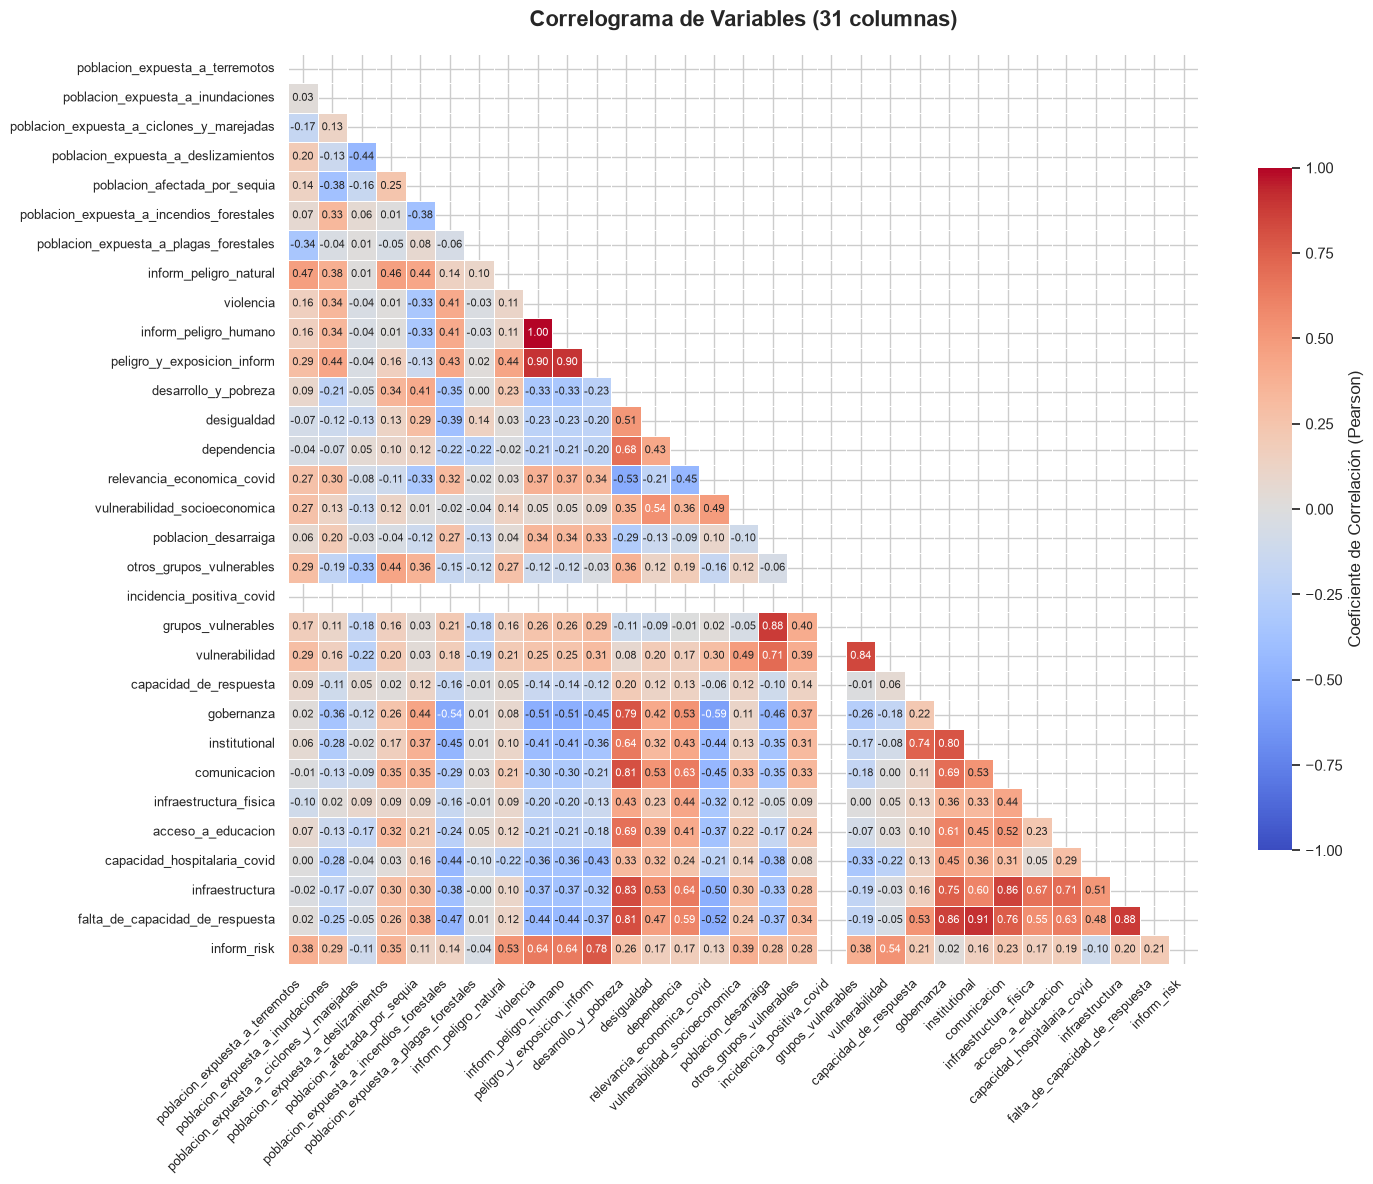

In [308]:
risk_indicators_1.shape
correlation_matrix(risk_indicators_1,mostrar_numeros=True)

In [336]:
risk_indicators_1.describe()

,poblacion_expuesta_a_terremotos,poblacion_expuesta_a_inundaciones,poblacion_expuesta_a_ciclones_y_marejadas,poblacion_expuesta_a_deslizamientos,poblacion_afectada_por_sequia,poblacion_expuesta_a_incendios_forestales,poblacion_expuesta_a_plagas_forestales,inform_peligro_natural,violencia,inform_peligro_humano,...,capacidad_de_respuesta,gobernanza,institutional,comunicacion,infraestructura_fisica,acceso_a_educacion,capacidad_hospitalaria_covid,infraestructura,falta_de_capacidad_de_respuesta,inform_risk
count,298.000000,276.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,...,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000
mean,4.708054,5.535870,0.473490,6.103691,3.601007,7.046309,2.256040,5.187584,4.167450,4.167450,...,5.535570,5.676174,5.788926,6.740268,7.517785,5.375839,9.677852,7.343624,6.680537,5.796644
std,3.354981,3.502973,1.831928,2.626725,3.828534,0.562764,2.565187,1.086346,3.133545,3.133545,...,2.023351,2.230294,1.708676,1.932059,1.772361,1.391032,1.162074,1.107296,1.242658,0.777713
min,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,2.400000,0.000000,0.000000,...,0.700000,0.000000,0.400000,0.400000,1.400000,1.100000,4.000000,3.600000,2.200000,3.400000
25%,0.000000,2.675000,0.000000,4.600000,0.000000,6.600000,0.000000,4.400000,1.325000,1.325000,...,3.300000,4.125000,4.625000,5.500000,6.400000,4.500000,10.000000,6.700000,6.000000,5.300000
50%,6.500000,5.550000,0.000000,6.100000,3.850000,7.000000,1.300000,5.300000,3.950000,3.950000,...,6.700000,5.950000,6.000000,6.900000,7.900000,5.400000,10.000000,7.600000,6.850000,5.800000
75%,7.100000,8.900000,0.000000,8.650000,6.675000,7.400000,3.900000,6.000000,6.800000,6.800000,...,6.700000,7.400000,7.100000,8.300000,9.000000,6.375000,10.000000,8.100000,7.500000,6.300000
max,10.000000,10.000000,9.700000,10.000000,10.000000,9.100000,9.100000,7.500000,10.000000,10.000000,...,10.000000,9.900000,9.600000,10.000000,10.200000,9.400000,10.000000,9.700000,9.200000,7.600000


In [337]:
risk_indicators_1.columns

Index(['municipio', 'poblacion_expuesta_a_terremotos',
       'poblacion_expuesta_a_inundaciones',
       'poblacion_expuesta_a_ciclones_y_marejadas',
       'poblacion_expuesta_a_deslizamientos', 'poblacion_afectada_por_sequia',
       'poblacion_expuesta_a_incendios_forestales',
       'poblacion_expuesta_a_plagas_forestales', 'inform_peligro_natural',
       'violencia', 'inform_peligro_humano', 'peligro_y_exposicion_inform',
       'desarrollo_y_pobreza', 'desigualdad', 'dependencia',
       'relevancia_economica_covid', 'vulnerabilidad_socioeconomica',
       'poblacion_desarraiga', 'otros_grupos_vulnerables',
       'incidencia_positiva_covid', 'grupos_vulnerables', 'vulnerabilidad',
       'capacidad_de_respuesta', 'gobernanza', 'institutional', 'comunicacion',
       'infraestructura_fisica', 'acceso_a_educacion',
       'capacidad_hospitalaria_covid', 'infraestructura',
       'falta_de_capacidad_de_respuesta', 'inform_risk'],
      dtype='str')

## Indicadores Riesgo 2

In [309]:
risk_indicators_2.columns = [
    remove_accent(col).strip().lower().replace(" ", "_") 
    for col in risk_indicators_2.columns
]
risk_indicators_2.head(15)



,municipio,inform_peligro_natural,inform_peligro_humano,peligro_y_exposicion_inform,vulnerabilidad_socioeconomica,grupos_vulnerables,vulnerabilidad,institutional,infraestructura,falta_de_capacidad_de_respuesta,...,socioeconomica,grupos,vulnerabilidad,institutional,infraestructura,faltadecapacidad,inform,unnamed:_29,unnamed:_30,unnamed:_31
0,La Ceiba,5.2,10.0,8.5,6.6,7.4,7.0,3.0,4.2,3.6,...,7.7,6.3,7.1,8.3,7.5,7.9,7.5,NaN,NaN,NaN
1,El Porvenir,3.8,9.2,7.4,7.1,3.4,5.5,2.9,6.0,4.6,...,7.4,7.5,7.5,9.3,7.2,8.4,7.5,NaN,NaN,NaN
2,Esparta,4.9,8.0,6.7,7.5,4.1,6.1,3.7,7.0,5.6,...,7.9,5.0,6.7,8.6,6.7,7.8,7.4,NaN,NaN,NaN
3,Jutiapa,4.4,8.9,7.3,7.8,6.0,7.0,3.8,7.3,5.8,...,8.1,5.8,7.1,9.2,8.0,8.7,7.4,NaN,NaN,NaN
4,La Masica,4.4,8.8,7.2,7.4,5.3,6.5,2.8,6.0,4.6,...,8.0,4.6,6.6,9.1,8.3,8.7,7.4,NaN,NaN,NaN
5,San Francisco,3.5,7.4,5.8,6.8,3.9,5.5,3.2,6.2,4.9,...,7.9,6.6,7.3,6.0,7.5,6.8,7.3,NaN,NaN,NaN
6,Tela,6.0,9.7,8.4,7.3,7.7,7.5,2.6,5.5,4.2,...,7.8,4.6,6.5,8.8,8.3,8.6,7.3,NaN,NaN,NaN
7,Arizona,4.1,8.9,7.2,7.5,4.7,6.3,3.4,5.9,4.8,...,7.8,6.2,7.1,8.2,7.9,8.1,7.3,NaN,NaN,NaN
8,Trujillo,4.0,0.9,2.6,6.6,8.3,7.6,3.0,6.3,4.9,...,8.3,6.8,7.6,6.6,8.0,7.4,7.2,NaN,NaN,NaN
9,Balfate,4.1,2.9,3.5,7.6,4.9,6.4,5.9,8.5,7.4,...,8.1,4.1,6.5,9.7,8.1,9.0,7.2,NaN,NaN,NaN


In [310]:
risk_indicators_2.columns

Index(['municipio', 'inform_peligro_natural', 'inform_peligro_humano',
       'peligro_y_exposicion_inform', 'vulnerabilidad_socioeconomica',
       'grupos_vulnerables', 'vulnerabilidad', 'institutional',
       'infraestructura', 'falta_de_capacidad_de_respuesta', 'inform_risk',
       'unnamed:_11', 'unnamed:_12', 'unnamed:_13', 'unnamed:_14',
       'unnamed:_15', 'unnamed:_16', 'codigo', 'municipio.1', 'pnatural',
       'phumano', 'peligroyexposicion', 'socioeconomica', 'grupos',
       'vulnerabilidad', 'institutional', 'infraestructura',
       'faltadecapacidad', 'inform', 'unnamed:_29', 'unnamed:_30',
       'unnamed:_31'],
      dtype='str')

Generando correlograma para 22 columnas numéricas...


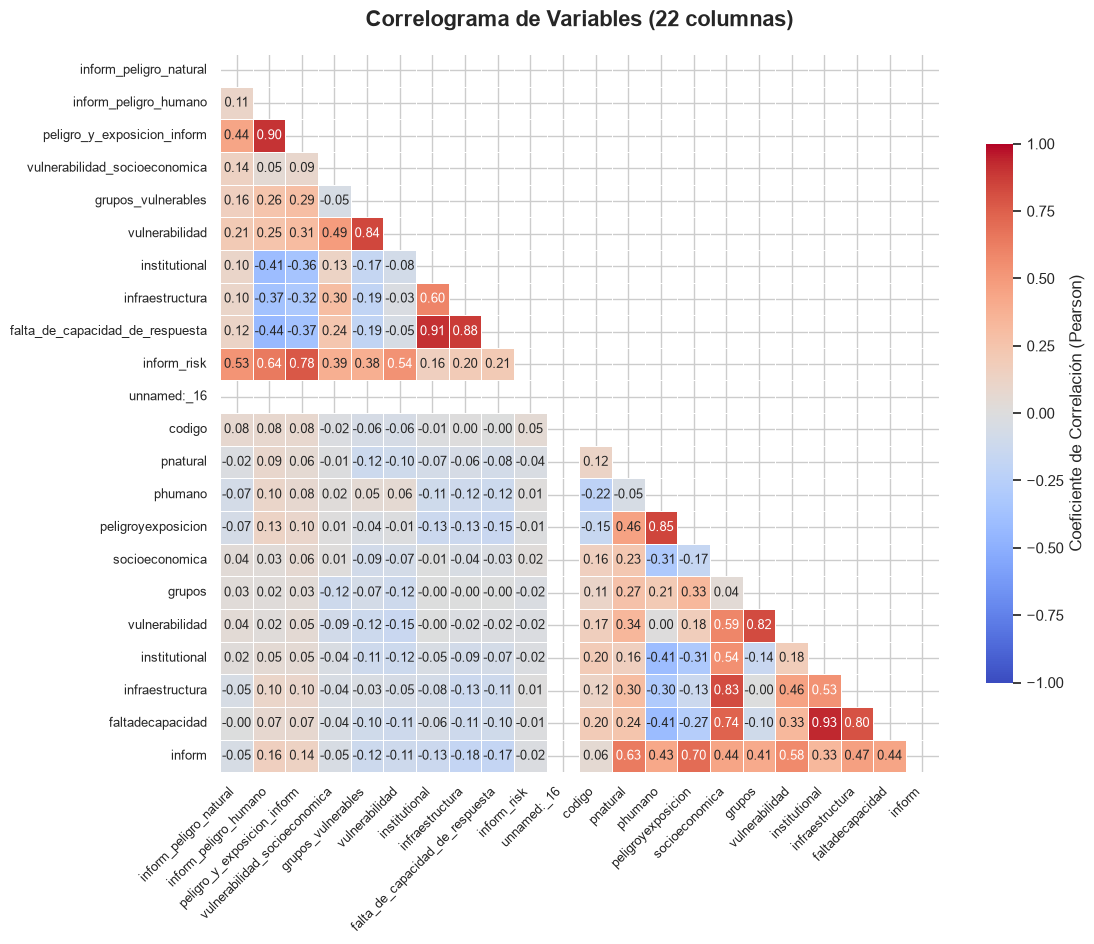

In [311]:
risk_indicators_2
df_temp=risk_indicators_2.iloc[:,1:11]
df_temp_2= risk_indicators_2.iloc[:,16:29]
risk_indicators_2=pd.concat([df_temp, df_temp_2], axis=1)
correlation_matrix(risk_indicators_2,mostrar_numeros=True)

In [312]:
risk_indicators_2.describe()

,inform_peligro_natural,inform_peligro_humano,peligro_y_exposicion_inform,vulnerabilidad_socioeconomica,grupos_vulnerables,vulnerabilidad,institutional,infraestructura,falta_de_capacidad_de_respuesta,inform_risk,...,pnatural,phumano,peligroyexposicion,socioeconomica,grupos,vulnerabilidad,institutional,infraestructura,faltadecapacidad,inform
count,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,...,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000
mean,5.187584,4.167450,4.908054,7.263423,5.039597,6.348993,5.788926,7.343624,6.680537,5.796644,...,4.604698,4.167450,4.674497,7.190940,4.850000,6.233893,6.636577,6.284564,6.574161,5.586913
std,1.086346,3.133545,1.746416,0.672378,1.581685,0.784455,1.708676,1.107296,1.242658,0.777713,...,1.722962,3.133545,1.855419,0.865083,1.661917,0.901155,2.148848,1.448195,1.615946,0.992258
min,2.400000,0.000000,1.300000,4.500000,1.600000,3.400000,0.400000,3.600000,2.200000,3.400000,...,0.000000,0.000000,0.500000,4.400000,1.000000,3.000000,1.300000,1.900000,2.500000,2.400000
25%,4.400000,1.325000,3.600000,6.800000,3.900000,5.800000,4.625000,6.700000,6.000000,5.300000,...,3.400000,1.325000,3.400000,6.700000,3.800000,5.700000,5.000000,5.300000,5.500000,5.100000
50%,5.300000,3.950000,4.500000,7.300000,4.800000,6.350000,6.000000,7.600000,6.850000,5.800000,...,4.700000,3.950000,4.600000,7.300000,4.800000,6.400000,7.000000,6.450000,6.900000,5.700000
75%,6.000000,6.800000,6.100000,7.700000,6.100000,6.900000,7.100000,8.100000,7.500000,6.300000,...,5.900000,6.800000,6.000000,7.900000,6.000000,6.800000,8.600000,7.300000,7.800000,6.300000
max,7.500000,10.000000,9.000000,8.900000,9.000000,8.600000,9.600000,9.700000,9.200000,7.600000,...,8.100000,10.000000,8.900000,8.800000,9.000000,8.600000,9.700000,9.600000,9.200000,7.500000


In [313]:
risk_indicators_2.columns

Index(['inform_peligro_natural', 'inform_peligro_humano',
       'peligro_y_exposicion_inform', 'vulnerabilidad_socioeconomica',
       'grupos_vulnerables', 'vulnerabilidad', 'institutional',
       'infraestructura', 'falta_de_capacidad_de_respuesta', 'inform_risk',
       'unnamed:_16', 'codigo', 'municipio.1', 'pnatural', 'phumano',
       'peligroyexposicion', 'socioeconomica', 'grupos', 'vulnerabilidad',
       'institutional', 'infraestructura', 'faltadecapacidad', 'inform'],
      dtype='str')

## Seleccion de Variables 

Generando correlograma para 9 columnas numéricas...


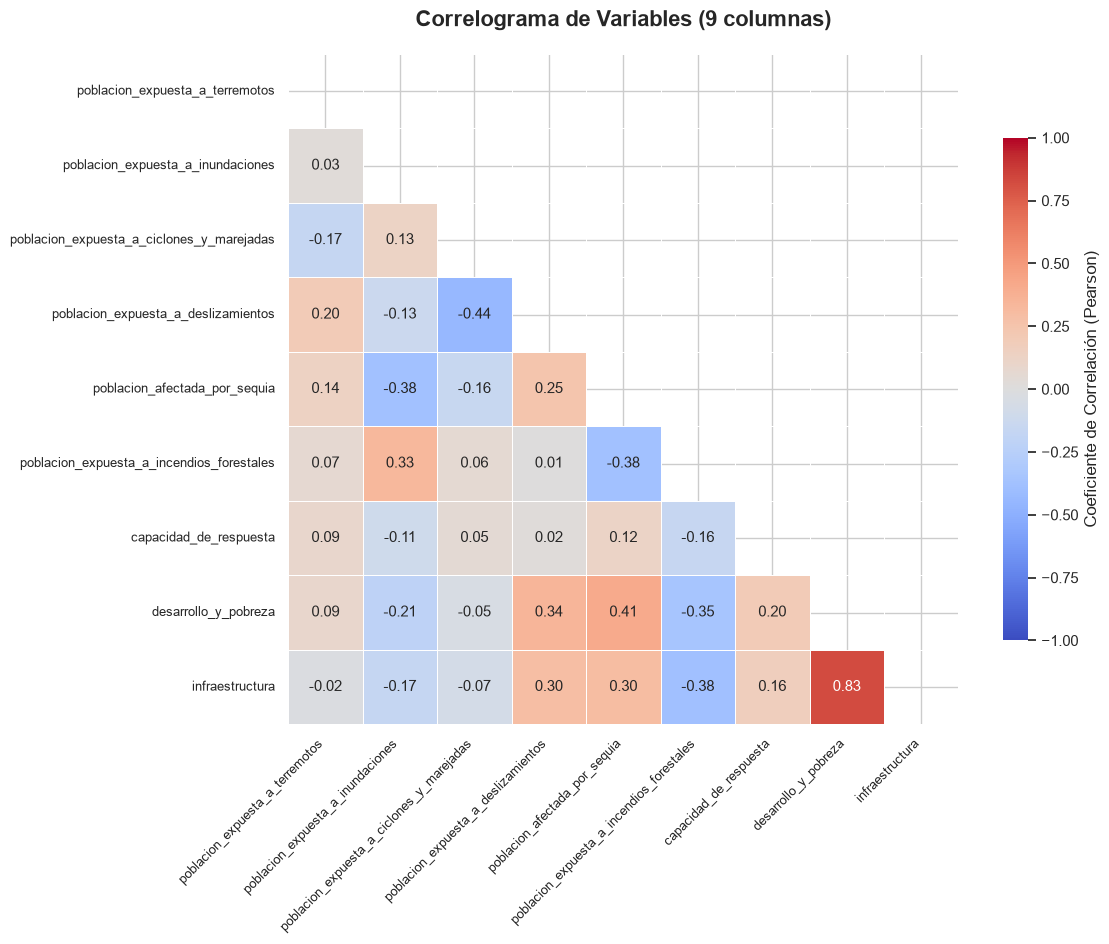

In [314]:
## Seleccion de indicadores
key_risk_indicators=["municipio","poblacion_expuesta_a_terremotos","poblacion_expuesta_a_inundaciones",
"poblacion_expuesta_a_ciclones_y_marejadas","poblacion_expuesta_a_deslizamientos",
"poblacion_afectada_por_sequia","poblacion_expuesta_a_incendios_forestales","capacidad_de_respuesta","desarrollo_y_pobreza","infraestructura"
]

selected_indicators=risk_indicators_1[key_risk_indicators]
correlation_matrix(selected_indicators,mostrar_numeros=True)

df_departamental=pd.read_csv("../data/index/processed/departamentos.csv")

selected_indicators=pd.concat([selected_indicators,df_departamental],axis=1)
selected_indicators["codigo"]=selected_indicators["codigo"].astype(str).str.zfill(4)
selected_indicators["codigo"]=["HN"+code for code in selected_indicators["codigo"]]


In [338]:
selected_indicators.describe()

,poblacion_expuesta_a_terremotos,poblacion_expuesta_a_inundaciones,poblacion_expuesta_a_ciclones_y_marejadas,poblacion_expuesta_a_deslizamientos,poblacion_afectada_por_sequia,poblacion_expuesta_a_incendios_forestales,capacidad_de_respuesta,desarrollo_y_pobreza,infraestructura
count,298.000000,276.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000
mean,4.708054,5.535870,0.473490,6.103691,3.601007,7.046309,5.535570,7.404362,7.343624
std,3.354981,3.502973,1.831928,2.626725,3.828534,0.562764,2.023351,1.188617,1.107296
min,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.700000,4.300000,3.600000
25%,0.000000,2.675000,0.000000,4.600000,0.000000,6.600000,3.300000,6.600000,6.700000
50%,6.500000,5.550000,0.000000,6.100000,3.850000,7.000000,6.700000,7.400000,7.600000
75%,7.100000,8.900000,0.000000,8.650000,6.675000,7.400000,6.700000,8.200000,8.100000
max,10.000000,10.000000,9.700000,10.000000,10.000000,9.100000,10.000000,10.000000,9.700000


In [341]:
selected_indicators.columns

Index(['municipio', 'poblacion_expuesta_a_terremotos',
       'poblacion_expuesta_a_inundaciones',
       'poblacion_expuesta_a_ciclones_y_marejadas',
       'poblacion_expuesta_a_deslizamientos', 'poblacion_afectada_por_sequia',
       'poblacion_expuesta_a_incendios_forestales', 'capacidad_de_respuesta',
       'desarrollo_y_pobreza', 'infraestructura', 'municipio', 'codigo',
       'departamento'],
      dtype='str')

In [346]:
def histogramas_numericos(df):
    # Seleccionar únicamente columnas numéricas
    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:
        # Estadísticas
        media = df[col].mean()
        desviacion_std = df[col].std()
        varianza = df[col].var()

        # Crear figura individual
        plt.figure(figsize=(10, 6))

        sns.histplot(
            data=df,
            x=col,
            bins=30,
            kde=True
        )

        # Título
        plt.title(f"Distribución de {col}", fontsize=14)

        # Texto con estadísticas
        texto = (
            f"Media: {media:.4f}\n"
            f"Desv. estándar: {desviacion_std:.4f}\n"
            f"Varianza: {varianza:.4f}"
        )

        plt.text(
            0.98, 0.95,
            texto,
            transform=plt.gca().transAxes,
            verticalalignment="top",
            horizontalalignment="right",
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                alpha=0.8
            )
        )

        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.tight_layout()
        plt.show()

        # Estadísticas copiables en consola
        print(f"\n{'=' * 60}")
        print(f"Variable: {col}")
        print(f"Media: {media:.6f}")
        print(f"Desviación estándar: {desviacion_std:.6f}")
        print(f"Varianza: {varianza:.6f}")
def histogramas_por_departamento(df, departamento):
    # Filtrar departamento
    df_departamento = df[
        df["departamento"].str.strip().str.lower() == departamento.strip().lower()
    ].copy()

    if df_departamento.empty:
        print(f"No se encontraron datos para el departamento: {departamento}")
        return

    print(f"\nDepartamento: {departamento}")
    print(f"Registros: {len(df_departamento)}")

    # Seleccionar columnas numéricas
    numeric_cols = df_departamento.select_dtypes(include="number").columns

    for col in numeric_cols:
        media = df_departamento[col].mean()
        desviacion_std = df_departamento[col].std()
        varianza = df_departamento[col].var()

        plt.figure(figsize=(10, 6))

        sns.histplot(
            data=df_departamento,
            x=col,
            bins=30,
            kde=True
        )

        plt.title(
            f"Distribución de {col} - {departamento}",
            fontsize=14
        )

        texto = (
            f"Media: {media:.4f}\n"
            f"Desv. estándar: {desviacion_std:.4f}\n"
            f"Varianza: {varianza:.4f}"
        )

        plt.text(
            0.98, 0.95,
            texto,
            transform=plt.gca().transAxes,
            verticalalignment="top",
            horizontalalignment="right",
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                alpha=0.8
            )
        )

        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        plt.tight_layout()
        plt.show()

        print(f"\n{'=' * 60}")
        print(f"Departamento: {departamento}")
        print(f"Variable: {col}")
        print(f"Media: {media:.6f}")
        print(f"Desviación estándar: {desviacion_std:.6f}")
        print(f"Varianza: {varianza:.6f}")


Departamento: Cortés
Registros: 12


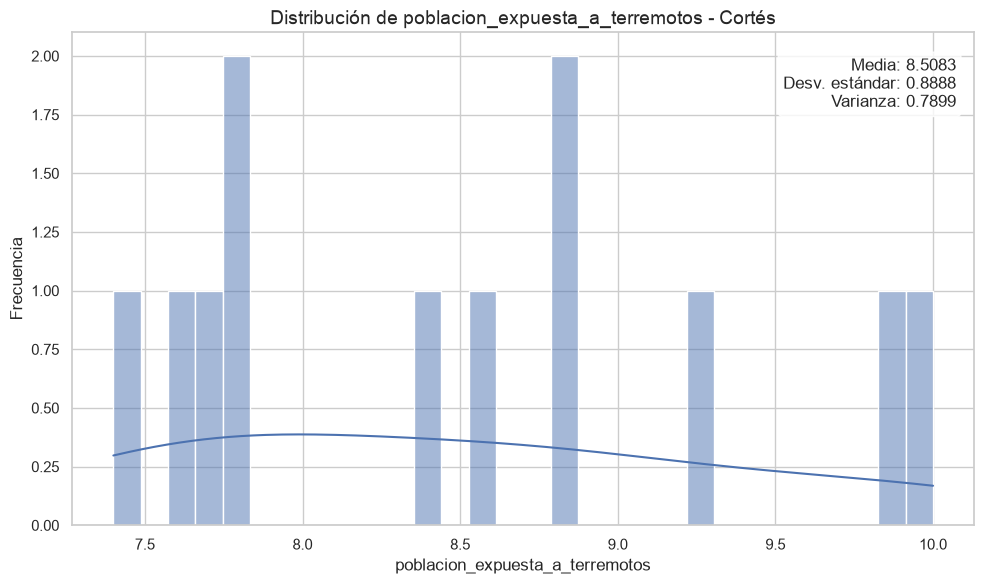


Departamento: Cortés
Variable: poblacion_expuesta_a_terremotos
Media: 8.508333
Desviación estándar: 0.888777
Varianza: 0.789924


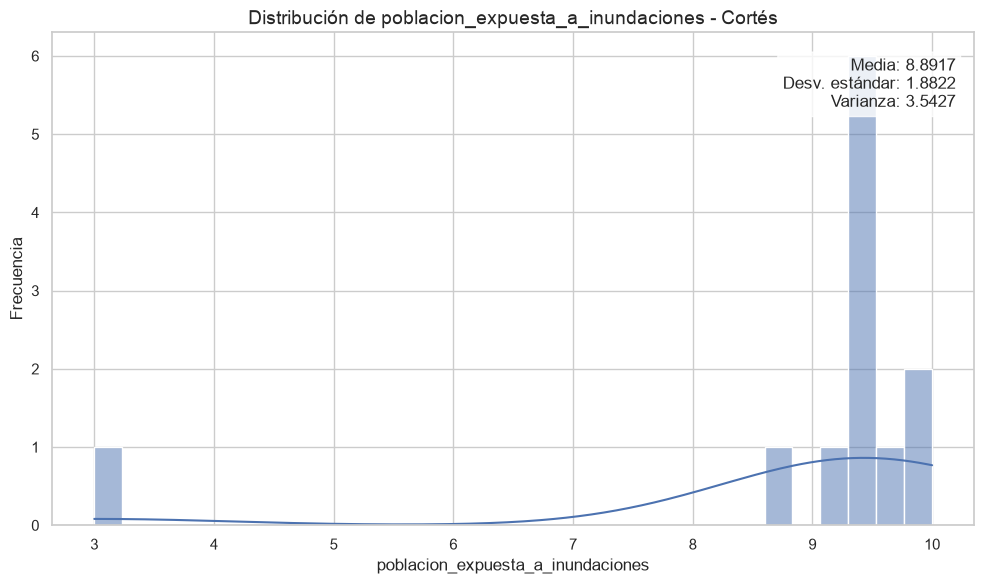


Departamento: Cortés
Variable: poblacion_expuesta_a_inundaciones
Media: 8.891667
Desviación estándar: 1.882193
Varianza: 3.542652


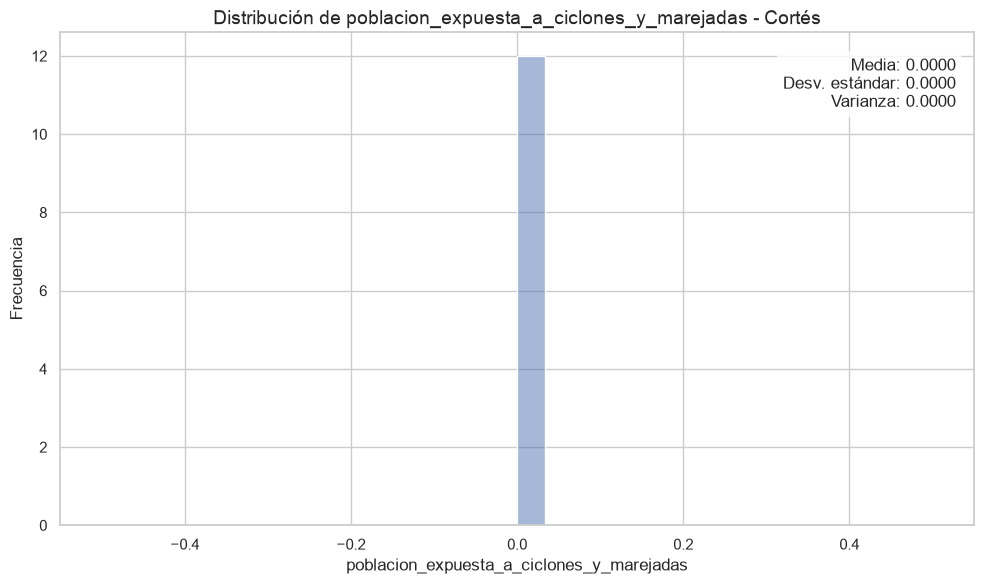


Departamento: Cortés
Variable: poblacion_expuesta_a_ciclones_y_marejadas
Media: 0.000000
Desviación estándar: 0.000000
Varianza: 0.000000


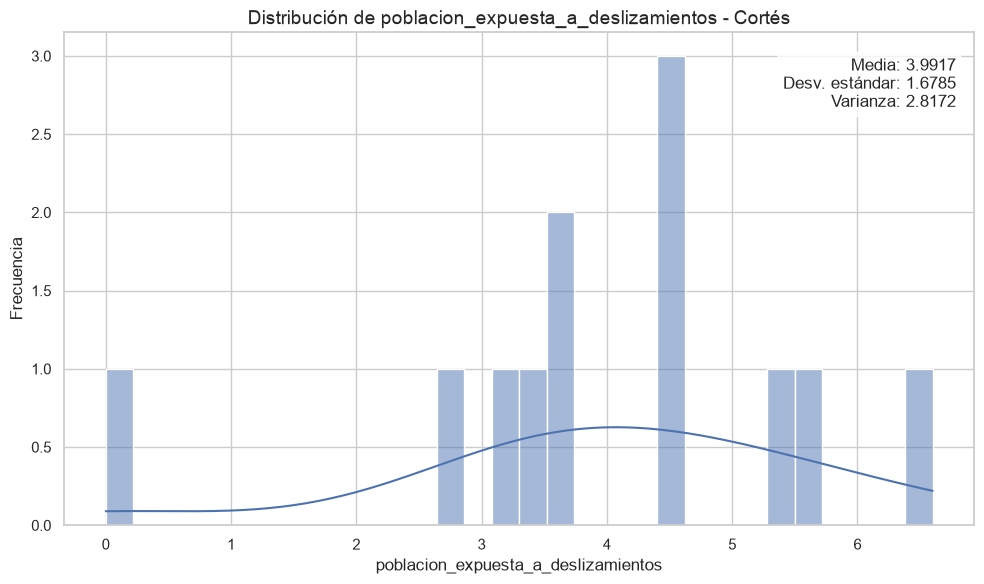


Departamento: Cortés
Variable: poblacion_expuesta_a_deslizamientos
Media: 3.991667
Desviación estándar: 1.678451
Varianza: 2.817197


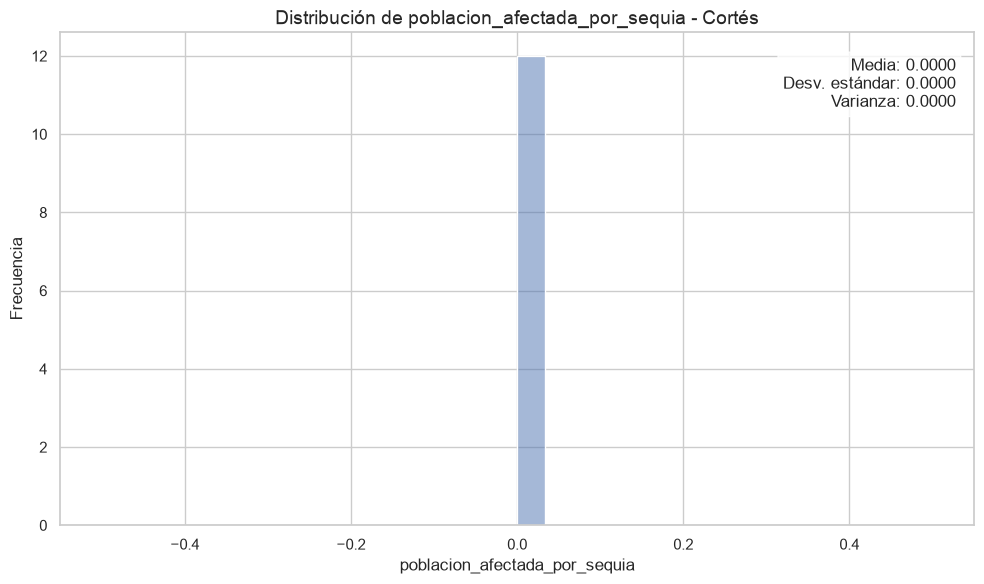


Departamento: Cortés
Variable: poblacion_afectada_por_sequia
Media: 0.000000
Desviación estándar: 0.000000
Varianza: 0.000000


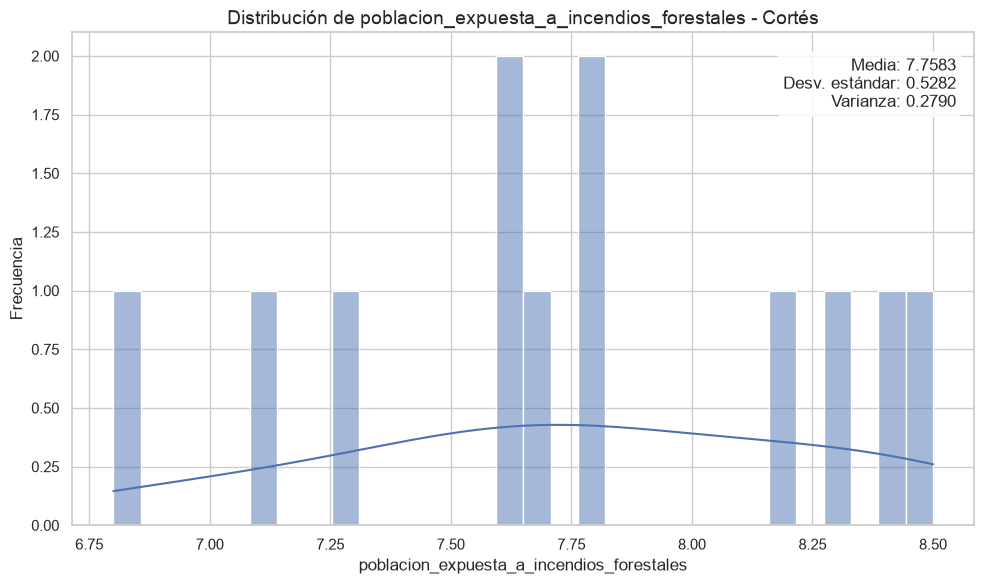


Departamento: Cortés
Variable: poblacion_expuesta_a_incendios_forestales
Media: 7.758333
Desviación estándar: 0.528219
Varianza: 0.279015


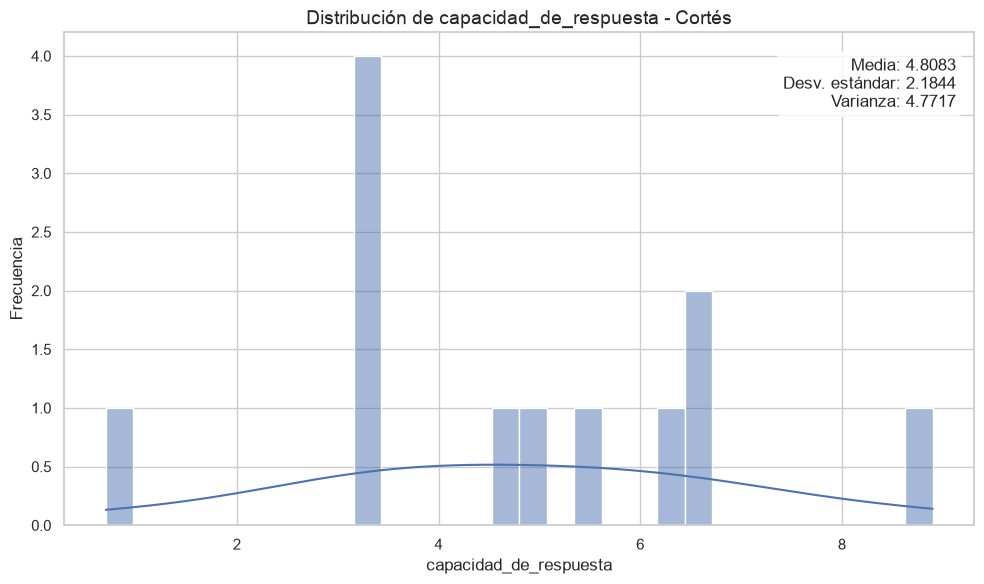


Departamento: Cortés
Variable: capacidad_de_respuesta
Media: 4.808333
Desviación estándar: 2.184432
Varianza: 4.771742


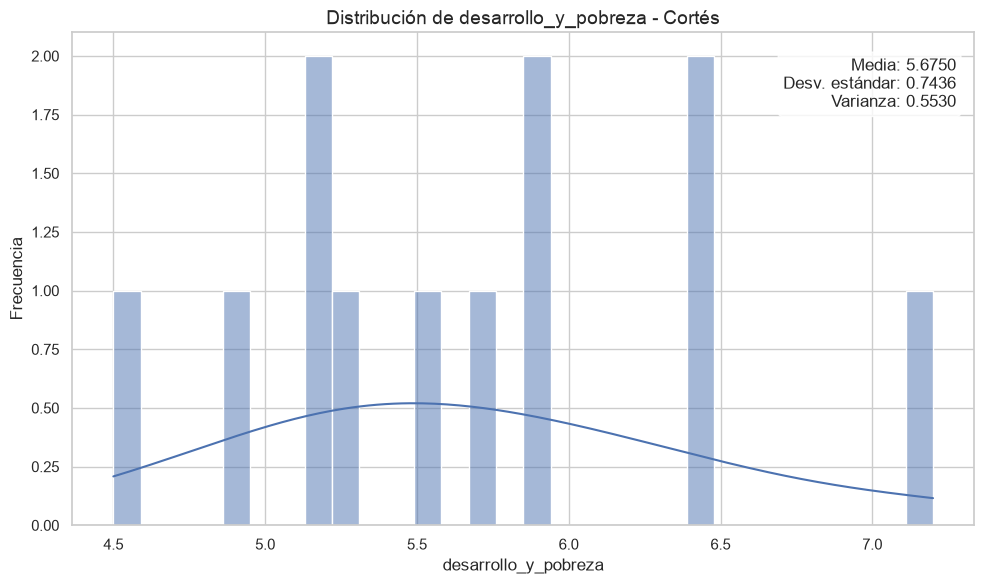


Departamento: Cortés
Variable: desarrollo_y_pobreza
Media: 5.675000
Desviación estándar: 0.743609
Varianza: 0.552955


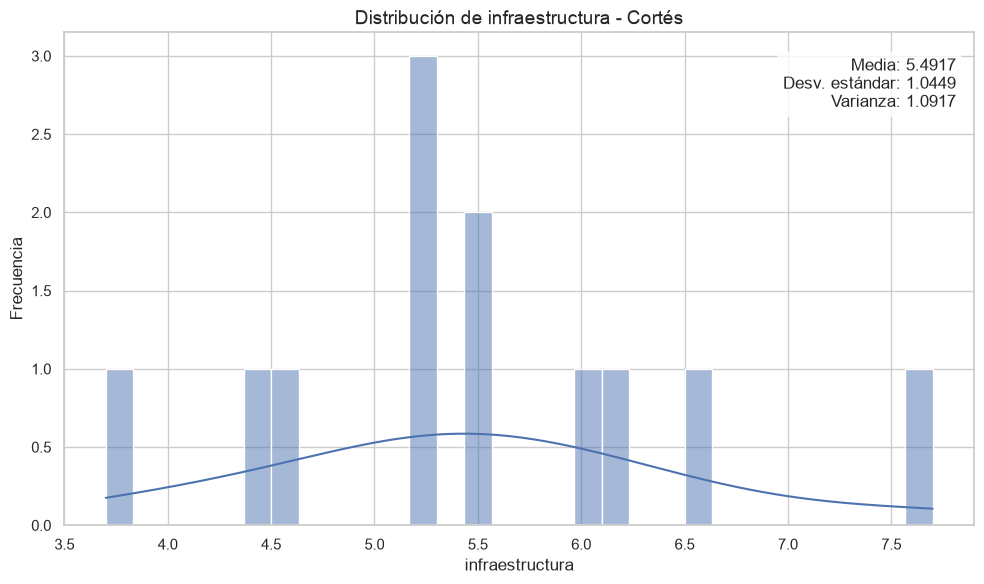


Departamento: Cortés
Variable: infraestructura
Media: 5.491667
Desviación estándar: 1.044865
Varianza: 1.091742


In [351]:
histogramas_por_departamento(selected_indicators,"Cortés")

## Correlograma 
Practicamten vamos a descargar infraestructura y nos 
quedamos con desarrollo y pobreza por estar fuerntemente correlacionaddas

In [315]:
selected_indicators.describe()


,poblacion_expuesta_a_terremotos,poblacion_expuesta_a_inundaciones,poblacion_expuesta_a_ciclones_y_marejadas,poblacion_expuesta_a_deslizamientos,poblacion_afectada_por_sequia,poblacion_expuesta_a_incendios_forestales,capacidad_de_respuesta,desarrollo_y_pobreza,infraestructura
count,298.000000,276.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000
mean,4.708054,5.535870,0.473490,6.103691,3.601007,7.046309,5.535570,7.404362,7.343624
std,3.354981,3.502973,1.831928,2.626725,3.828534,0.562764,2.023351,1.188617,1.107296
min,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.700000,4.300000,3.600000
25%,0.000000,2.675000,0.000000,4.600000,0.000000,6.600000,3.300000,6.600000,6.700000
50%,6.500000,5.550000,0.000000,6.100000,3.850000,7.000000,6.700000,7.400000,7.600000
75%,7.100000,8.900000,0.000000,8.650000,6.675000,7.400000,6.700000,8.200000,8.100000
max,10.000000,10.000000,9.700000,10.000000,10.000000,9.100000,10.000000,10.000000,9.700000


## Solar Power
Vamos a trabajar con el dataset de energia solar. 
El dataset contiene totales anuales por municipio de la energia solar, tomando en cuenta un promedio un maximo y un minimo de KWh

In [316]:
solar_power_df=pd.read_csv("../data/GIS_Data_SolarPower/processed/yearly_monthly_totals.csv")
solar_power_df.head()
columns = {
    'mean':'solar_power_mean',
    'max':'solar_power_max',
    'min':'solar_power_min'
}

solar_power_df=solar_power_df.rename(columns=columns)

In [317]:
solar_power_df.describe()

,solar_power_mean,solar_power_min,solar_power_max
count,298.000000,298.000000,298.000000
mean,1947.962275,1747.255492,2040.474014
std,124.547439,187.831318,105.892908
min,1704.986230,1117.665039,1810.178955
25%,1848.401302,1631.846008,1960.388245
50%,1906.674725,1735.119995,2008.692505
75%,2041.931424,1863.322723,2136.712646
max,2255.330428,2214.145996,2264.915039


In [318]:
## union de los datasets usadno los codigos, 
merge_dataset=pd.merge(
    solar_power_df, selected_indicators,left_on="codigo_municipal",right_on="codigo",how="inner")
merge_dataset.shape

(298, 20)

In [319]:
merge_dataset[merge_dataset["municipio_x"]=="La Lima"]

,departamento_x,municipio_x,solar_power_mean,solar_power_min,solar_power_max,codigo_departamental,codigo_municipal,municipio_y,poblacion_expuesta_a_terremotos,poblacion_expuesta_a_inundaciones,poblacion_expuesta_a_ciclones_y_marejadas,poblacion_expuesta_a_deslizamientos,poblacion_afectada_por_sequia,poblacion_expuesta_a_incendios_forestales,capacidad_de_respuesta,desarrollo_y_pobreza,infraestructura,municipio_y,codigo,departamento_y
28,Cortes,La Lima,1969.962451,1944.956055,1990.612061,HN05,HN0512,La Lima,8.8,9.7,0.0,4.6,0.0,7.8,3.3,4.9,5.3,La Lima,HN0512,Cortés


In [320]:
risk_indicators_1.shape

(298, 32)

In [321]:
merge_dataset.shape

(298, 20)

In [322]:
merge_dataset.head()

,departamento_x,municipio_x,solar_power_mean,solar_power_min,solar_power_max,codigo_departamental,codigo_municipal,municipio_y,poblacion_expuesta_a_terremotos,poblacion_expuesta_a_inundaciones,poblacion_expuesta_a_ciclones_y_marejadas,poblacion_expuesta_a_deslizamientos,poblacion_afectada_por_sequia,poblacion_expuesta_a_incendios_forestales,capacidad_de_respuesta,desarrollo_y_pobreza,infraestructura,municipio_y,codigo,departamento_y
0,Islas De La Bahia,Guanaja,1988.934501,1898.935059,2023.484985,HN11,HN1102,Guanaja,0.0,0.0,8.8,0.0,0.0,6.6,3.3,4.5,4.7,Guanaja,HN1102,Islas de la Bahía
1,Islas De La Bahia,Jose Santos Guardiola,2012.974138,1978.923950,2032.615967,HN11,HN1103,José Santos Guardiola,0.0,1.3,7.6,0.0,0.0,6.8,6.7,5.2,5.5,José Santos Guardiola,HN1103,Islas de la Bahía
2,Islas De La Bahia,Roatan,2009.962306,1982.577026,2054.895996,HN11,HN1101,Roatan,0.0,5.5,7.6,0.0,0.0,8.1,6.7,4.4,5.1,Roatan,HN1101,Islas de la Bahía
3,Colon,Trujillo,1964.558803,1748.086060,2042.113037,HN02,HN0201,Trujillo,0.0,9.0,0.0,3.1,0.0,7.5,3.3,6.2,6.3,Trujillo,HN0201,Colón
4,Colon,Iriona,1791.207199,1471.227051,1977.828979,HN02,HN0203,Iriona,0.0,8.9,8.8,5.0,0.0,7.0,3.3,6.7,8.2,Iriona,HN0203,Colón


In [323]:
for col, dtype in merge_dataset.dtypes.items():
    print(f"{col}: {dtype}")

departamento_x: str
municipio_x: str
solar_power_mean: float64
solar_power_min: float64
solar_power_max: float64
codigo_departamental: str
codigo_municipal: str
municipio_y: str
poblacion_expuesta_a_terremotos: float64
poblacion_expuesta_a_inundaciones: float64
poblacion_expuesta_a_ciclones_y_marejadas: float64
poblacion_expuesta_a_deslizamientos: float64
poblacion_afectada_por_sequia: float64
poblacion_expuesta_a_incendios_forestales: float64
capacidad_de_respuesta: float64
desarrollo_y_pobreza: float64
infraestructura: float64
municipio_y: str
codigo: str
departamento_y: str


In [324]:
merge_dataset=merge_dataset.drop(columns=["municipio_y","codigo","departamento_y"])
merge_dataset=merge_dataset.rename(columns={
    "municipio_x":"municipio",
    "departamento_x":"departamento"
})

Generando correlograma para 12 columnas numéricas...


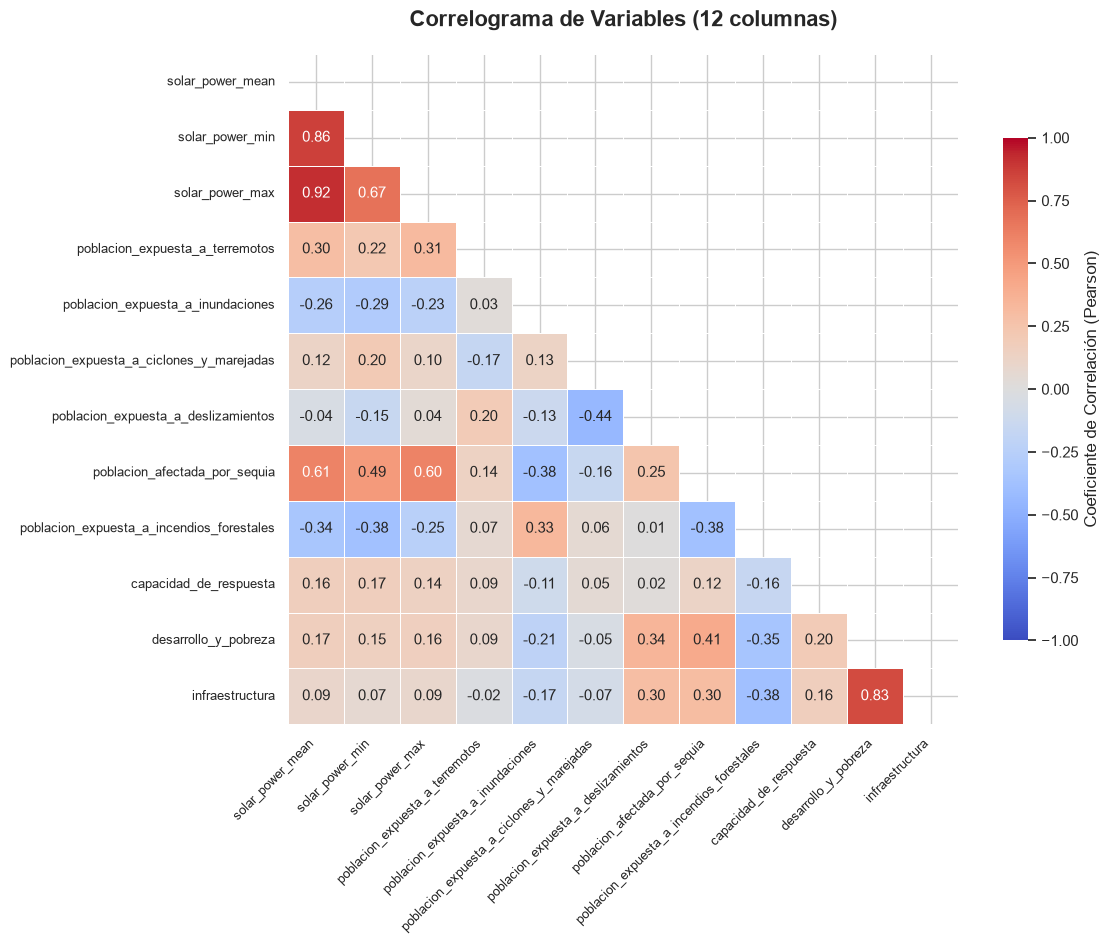

In [325]:
correlation_matrix(merge_dataset,mostrar_numeros=True)


### ICAEH DATASEt

In [326]:
def flatten_percentage(df_col):
    return df_col.str.replace('%', '', regex=False).astype(float) / 100


In [327]:
icaeh_df=pd.read_csv("../data/ICAEH/processed/ICAEH_2022.csv")


icaeh_df["IAE"]=flatten_percentage(icaeh_df["IAE"])
icaeh_df["ICE"]=flatten_percentage(icaeh_df["ICE"])
icaeh_df=icaeh_df.drop(columns=["VIVIENDAS", "COBERTURA"])
icaeh_df["DEPARTAMENTO"] = icaeh_df["DEPARTAMENTO"].str.lower().str.title().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
icaeh_df["MUNICIPIO"] = icaeh_df["MUNICIPIO"].str.title().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

icaeh_df.columns=icaeh_df.columns.str.lower()

In [328]:
print(icaeh_df.shape)
print(merge_dataset.shape)

(304, 4)
(298, 16)


In [329]:
icaeh_df.head()

,departamento,municipio,ice,iae
0,Atlantida,La Ceiba,0.9817,0.9831
1,Atlantida,El Porvenir,0.9656,0.9692
2,Atlantida,Esparta,0.6951,0.7047
3,Atlantida,Jutiapa,0.8146,0.8414
4,Atlantida,La Masica,0.6075,0.6231


In [330]:
merge_dataset.head()

,departamento,municipio,solar_power_mean,solar_power_min,solar_power_max,codigo_departamental,codigo_municipal,poblacion_expuesta_a_terremotos,poblacion_expuesta_a_inundaciones,poblacion_expuesta_a_ciclones_y_marejadas,poblacion_expuesta_a_deslizamientos,poblacion_afectada_por_sequia,poblacion_expuesta_a_incendios_forestales,capacidad_de_respuesta,desarrollo_y_pobreza,infraestructura
0,Islas De La Bahia,Guanaja,1988.934501,1898.935059,2023.484985,HN11,HN1102,0.0,0.0,8.8,0.0,0.0,6.6,3.3,4.5,4.7
1,Islas De La Bahia,Jose Santos Guardiola,2012.974138,1978.923950,2032.615967,HN11,HN1103,0.0,1.3,7.6,0.0,0.0,6.8,6.7,5.2,5.5
2,Islas De La Bahia,Roatan,2009.962306,1982.577026,2054.895996,HN11,HN1101,0.0,5.5,7.6,0.0,0.0,8.1,6.7,4.4,5.1
3,Colon,Trujillo,1964.558803,1748.086060,2042.113037,HN02,HN0201,0.0,9.0,0.0,3.1,0.0,7.5,3.3,6.2,6.3
4,Colon,Iriona,1791.207199,1471.227051,1977.828979,HN02,HN0203,0.0,8.9,8.8,5.0,0.0,7.0,3.3,6.7,8.2


In [331]:
merge_dataset["departamento"] = merge_dataset["departamento"].str.lower().str.title().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
merge_dataset["municipio"] = merge_dataset["municipio"].str.title().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

df_resultado = pd.merge(
    merge_dataset, 
    icaeh_df, 
    on=['departamento', 'municipio'], 
    how="left"  # Usa 'left', 'right' u 'outer' según tus necesidades
)

df_resultado = df_resultado.drop_duplicates(
    subset=["codigo_municipal"],
    keep="first"
).copy()


In [332]:
df_resultado.head(30)

,departamento,municipio,solar_power_mean,solar_power_min,solar_power_max,codigo_departamental,codigo_municipal,poblacion_expuesta_a_terremotos,poblacion_expuesta_a_inundaciones,poblacion_expuesta_a_ciclones_y_marejadas,poblacion_expuesta_a_deslizamientos,poblacion_afectada_por_sequia,poblacion_expuesta_a_incendios_forestales,capacidad_de_respuesta,desarrollo_y_pobreza,infraestructura,ice,iae
0,Islas De La Bahia,Guanaja,1988.934501,1898.935059,2023.484985,HN11,HN1102,0.0,0.0,8.8,0.0,0.0,6.6,3.3,4.5,4.7,NaN,NaN
1,Islas De La Bahia,Jose Santos Guardiola,2012.974138,1978.923950,2032.615967,HN11,HN1103,0.0,1.3,7.6,0.0,0.0,6.8,6.7,5.2,5.5,NaN,NaN
2,Islas De La Bahia,Roatan,2009.962306,1982.577026,2054.895996,HN11,HN1101,0.0,5.5,7.6,0.0,0.0,8.1,6.7,4.4,5.1,NaN,NaN
3,Colon,Trujillo,1964.558803,1748.086060,2042.113037,HN02,HN0201,0.0,9.0,0.0,3.1,0.0,7.5,3.3,6.2,6.3,0.9593,0.9642
4,Colon,Iriona,1791.207199,1471.227051,1977.828979,HN02,HN0203,0.0,8.9,8.8,5.0,0.0,7.0,3.3,6.7,8.2,0.0103,0.0963
5,Colon,Santa Rosa De Aguan,2005.910529,1962.854004,2033.712036,HN02,HN0207,0.0,8.8,7.6,2.7,0.0,7.6,7.1,7.9,7.7,0.8333,0.8418
6,Atlantida,Tela,1867.027152,1546.833984,2015.814941,HN01,HN0107,9.1,9.6,0.0,4.3,0.0,7.5,3.3,6.0,5.5,0.7356,0.7428
7,Colon,Limon,1904.417128,1807.987061,2012.527954,HN02,HN0204,0.0,8.7,7.4,3.7,0.0,7.4,6.7,8.2,8.5,0.7404,0.7454
8,Colon,Santa Fe,1880.939815,1721.422974,1955.182983,HN02,HN0206,0.0,8.9,0.0,0.0,4.9,6.4,6.7,6.6,6.9,0.9714,1.1070
9,Cortes,Puerto Cortes,1935.149874,1793.011963,2006.683960,HN05,HN0506,9.3,9.4,0.0,3.6,0.0,7.7,3.3,5.2,4.4,0.9700,0.9731


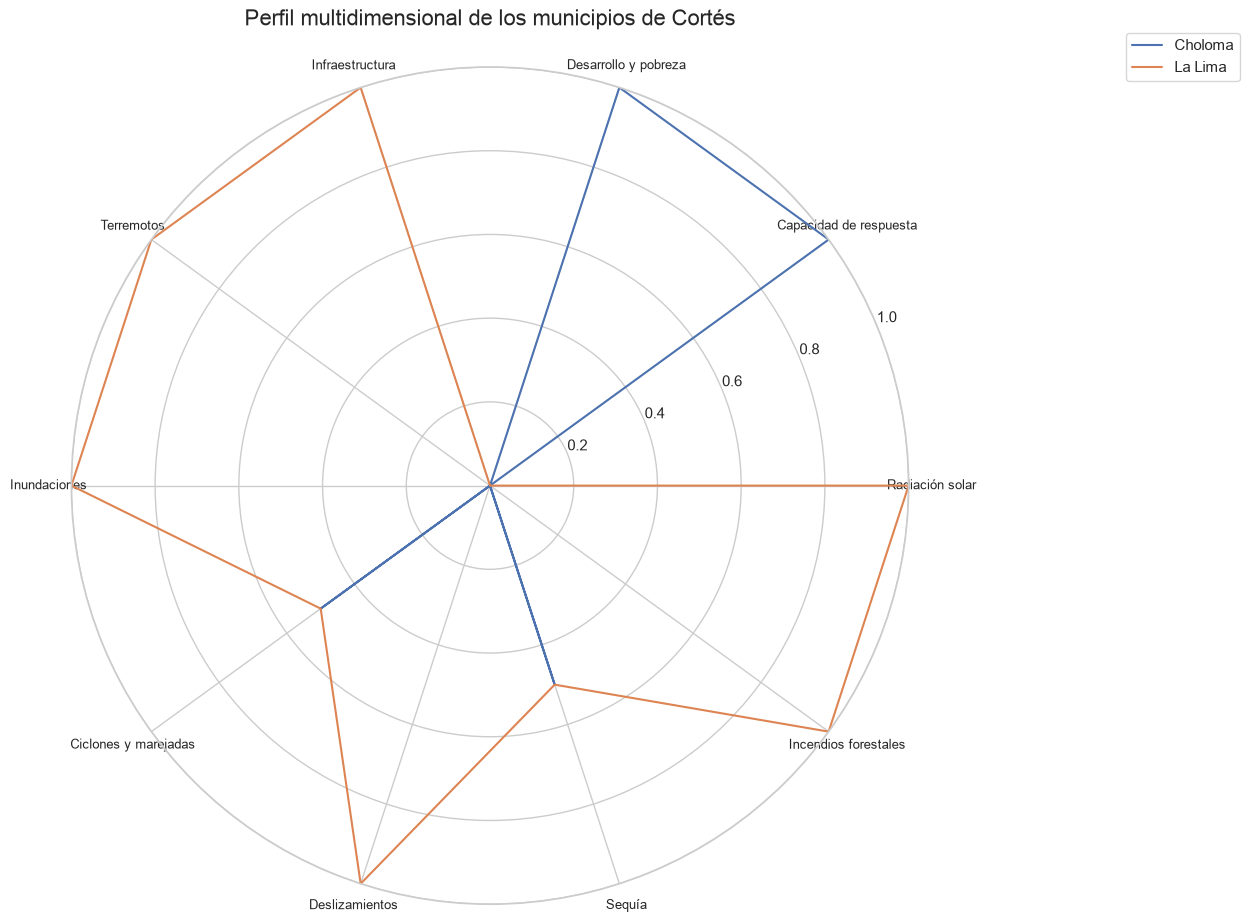

In [333]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. Seleccionar únicamente el departamento de Cortés
# ============================================================

cortes_df = df_resultado[
    (df_resultado["departamento"].str.strip().str.lower() == "cortes") &
    (df_resultado["municipio"].str.strip().str.lower().isin([
        "choloma",
        "la lima"
    ]))
].copy()

# ============================================================
# 2. Variables existentes en tu DataFrame
# ============================================================

variables = {
    "Radiación solar": "solar_power_mean",
    "Capacidad de respuesta": "capacidad_de_respuesta",
    "Desarrollo y pobreza": "desarrollo_y_pobreza",
    "Infraestructura": "infraestructura",
    "Terremotos": "poblacion_expuesta_a_terremotos",
    "Inundaciones": "poblacion_expuesta_a_inundaciones",
    "Ciclones y marejadas": "poblacion_expuesta_a_ciclones_y_marejadas",
    "Deslizamientos": "poblacion_expuesta_a_deslizamientos",
    "Sequía": "poblacion_afectada_por_sequia",
    "Incendios forestales": "poblacion_expuesta_a_incendios_forestales"
}


# ============================================================
# 3. Normalizar cada variable usando los municipios de Cortés
# ============================================================

for columna in variables.values():

    min_val = cortes_df[columna].min()
    max_val = cortes_df[columna].max()

    if max_val == min_val:
        cortes_df[f"{columna}_norm"] = 0.5
    else:
        cortes_df[f"{columna}_norm"] = (
            (cortes_df[columna] - min_val)
            / (max_val - min_val)
        )


# ============================================================
# 4. Invertir variables de riesgo
#
# Un valor alto de exposición = peor condición.
# Por eso:
#
#     1 = menor exposición
#     0 = mayor exposición
# ============================================================

variables_riesgo = [
    "poblacion_expuesta_a_terremotos",
    "poblacion_expuesta_a_inundaciones",
    "poblacion_expuesta_a_ciclones_y_marejadas",
    "poblacion_expuesta_a_deslizamientos",
    "poblacion_afectada_por_sequia",
    "poblacion_expuesta_a_incendios_forestales"
]

for columna in variables_riesgo:

    cortes_df[f"{columna}_norm"] = (
        1 - cortes_df[f"{columna}_norm"]
    )


# ============================================================
# 5. Configurar Spider Graph
# ============================================================

labels = list(variables.keys())

N = len(labels)

angles = np.linspace(
    0,
    2 * np.pi,
    N,
    endpoint=False
).tolist()

angles += angles[:1]


# ============================================================
# 6. Crear gráfica
# ============================================================

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(
    figsize=(13, 13),
    subplot_kw={"polar": True}
)


# ============================================================
# 7. Una línea por municipio
# ============================================================

for _, row in cortes_df.iterrows():

    values = [
        row[f"{columna}_norm"]
        for columna in variables.values()
    ]

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=1.5,
        label=row["municipio"]
    )


# ============================================================
# 8. Configuración visual
# ============================================================

ax.set_xticks(angles[:-1])

ax.set_xticklabels(
    labels,
    fontsize=9
)

ax.set_ylim(0, 1)

ax.set_title(
    "Perfil multidimensional de los municipios de Cortés",
    fontsize=16,
    pad=30
)

ax.legend(
    bbox_to_anchor=(1.25, 1.05),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [335]:
df_resultado.to_csv("../data/index/processed/dataset_indicadores.csv")